In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

In [ ]:
def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Decide step size to evenly sample frames
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)


def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    # Preprocess frames
    frames = preprocess_input(frames)

    # Predict
    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)

    # Decode top 5 predictions
    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    print("\nTop 5 Predictions:\n")
    for pred in top_pred[0]:
        print(pred[1], ":", round(pred[2] * 100, 2), "%")

    print("\nFinal Prediction:", top_pred[0][0][1])


# ✅ Your video path in Colab
video_path = "/content/real_world_demo_video.mp4"

classify_video(video_path)

Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top 5 Predictions:

digital_clock : 63.84 %
traffic_light : 9.13 %
switch : 1.43 %
computer_keyboard : 1.32 %
matchstick : 0.85 %

Final Prediction: digital_clock


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
# 1. Update imports to ResNet50
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# 2. Load pretrained ResNet50
model = ResNet50(weights='imagenet')

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames) if total_frames > 0 else 1
    count = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        count += 1
        if len(frames) >= max_frames: break

    cap.release()
    return np.array(frames)

def classify_video(video_path):
    frames = extract_frames(video_path)
    if len(frames) == 0:
        return

    # Preprocess frames using ResNet-specific logic
    frames = preprocess_input(frames.astype('float32'))

    predictions = model.predict(frames)
    avg_pred = np.mean(predictions, axis=0)
    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    print("\nTop 5 Predictions (ResNet50):\n")
    for pred in top_pred[0]:
        print(f"{pred[1]}: {round(pred[2] * 100, 2)}%")

video_path = "/content/real_world_demo_video.mp4"
classify_video(video_path)



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Top 5 Predictions (ResNet50):

envelope: 15.119999885559082%
web_site: 11.960000038146973%
tripod: 10.279999732971191%
digital_clock: 5.21999979019165%
crane: 4.170000076293945%


In [ ]:
frames = extract_frames(video_path)
if len(frames) > 0:
    print(f"Frames shape: {frames.shape}")
    print(f"First element of the first frame: {frames[0][0][0]}")
else:
    print("No frames were extracted.")

Frames shape: (20, 224, 224, 3)
First element of the first frame: [233 206 133]


In [ ]:
display(frames)

array([[[[233, 206, 133],
         [233, 206, 133],
         [233, 206, 133],
         ...,
         [233, 206, 133],
         [233, 206, 133],
         [233, 206, 133]],

        [[233, 206, 133],
         [233, 206, 133],
         [233, 206, 133],
         ...,
         [233, 206, 133],
         [233, 206, 133],
         [233, 206, 133]],

        [[233, 206, 133],
         [233, 206, 133],
         [233, 206, 133],
         ...,
         [233, 206, 133],
         [233, 206, 133],
         [233, 206, 133]],

        ...,

        [[ 46,  48,  45],
         [ 46,  48,  45],
         [ 46,  48,  45],
         ...,
         [ 46,  48,  45],
         [ 46,  48,  45],
         [ 46,  48,  45]],

        [[ 46,  48,  45],
         [ 46,  48,  45],
         [ 46,  48,  45],
         ...,
         [ 46,  48,  45],
         [ 46,  48,  45],
         [ 46,  48,  45]],

        [[ 46,  48,  45],
         [ 46,  48,  45],
         [ 46,  48,  45],
         ...,
         [ 46,  48,  45],
        

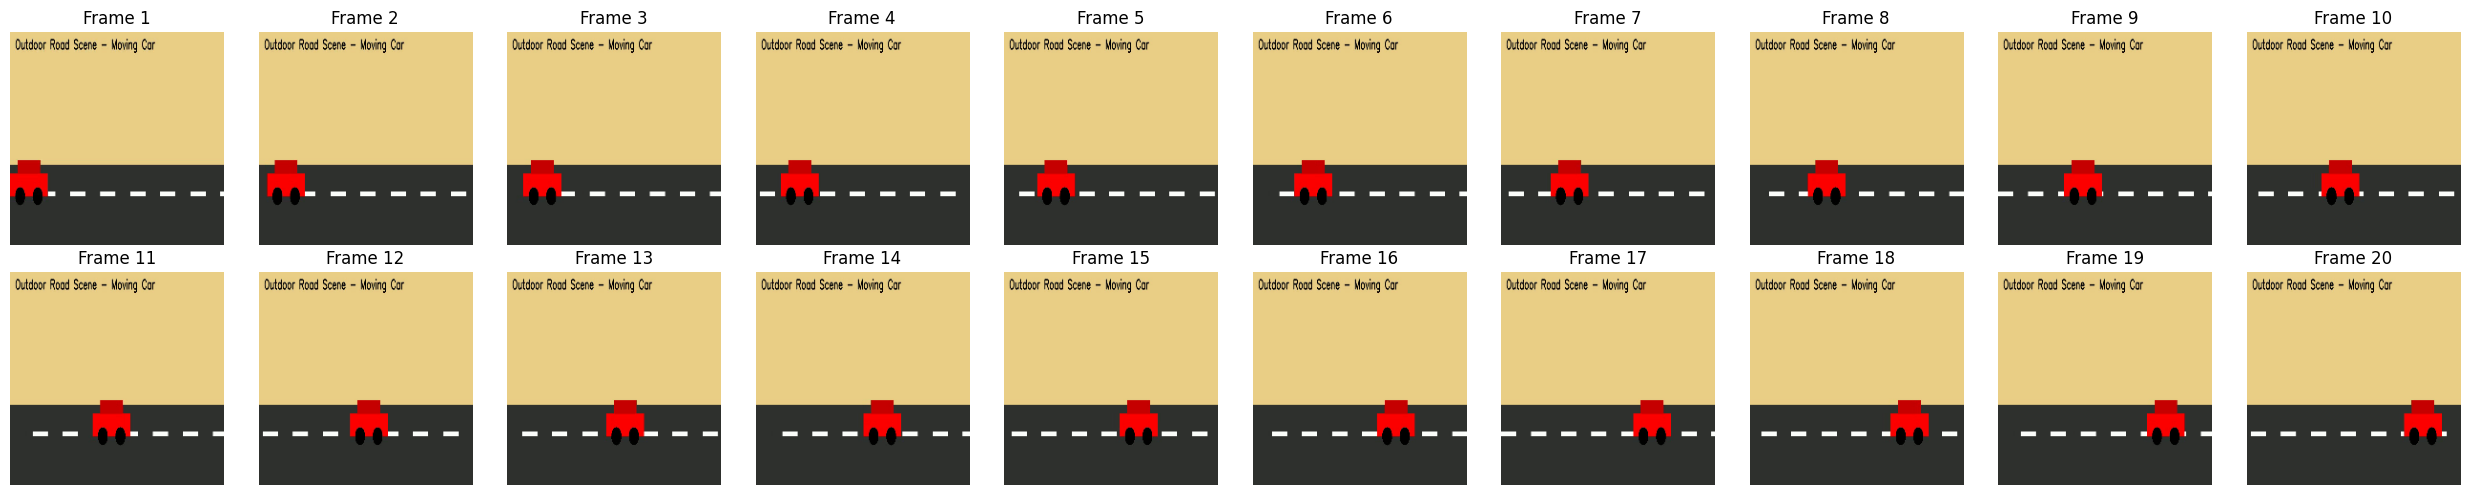

In [ ]:
import matplotlib.pyplot as plt

# Calculate number of rows and columns for the grid
num_frames = len(frames)
num_cols = 10  # You can adjust this for desired layout
num_rows = (num_frames + num_cols - 1) // num_cols # Ensure enough rows

plt.figure(figsize=(num_cols * 2.5, num_rows * 2.5)) # Adjust figure size dynamically

for i, frame in enumerate(frames):
    plt.subplot(num_rows, num_cols, i + 1) # Create subplot for each frame
    plt.imshow(frame)
    plt.title(f"Frame {i+1}")
    plt.axis('off') # Hide axes for cleaner image display

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [5]:
import cv2

video_path = "/content/real_world_demo_video.mp4"
cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Original Video Width: {width}")
    print(f"Original Video Height: {height}")
    print(f"Frames Per Second (FPS): {fps}")
    cap.release()
else:
    print("Error: Could not open video file.")

Original Video Width: 854
Original Video Height: 480
Frames Per Second (FPS): 24.0
